In [1]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.1 MB/s eta 0:00:00


# ***Importing Libraries***



In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm
from pyvis.network import Network
from networkx.algorithms import bipartite
from itertools import combinations
from collections import Counter
from collections import defaultdict
import community as community_louvain
from IPython.display import display, HTML

# Visualization settings
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

DATA_DIR = "/content/drive/MyDrive/NAML/"

Mounted at /content/drive


# ***Data Loading***

In [3]:
# File paths
person_path = os.path.join(DATA_DIR, "sampled_person.csv")
condition_path = os.path.join(DATA_DIR, "sampled_condition_occurrence.csv")
drug_path = os.path.join(DATA_DIR, "sampled_drug_exposure.csv")
concept_path = os.path.join(DATA_DIR, "concept.csv")
location_path = os.path.join(DATA_DIR, "location.csv")

# Data Loading
person_df = pd.read_csv(person_path)
condition_df = pd.read_csv(condition_path, low_memory=False)
drug_df = pd.read_csv(drug_path, low_memory=False)
concept_df = pd.read_csv(concept_path, low_memory=False)
location_df = pd.read_csv(location_path)

In [4]:
person_df.shape

(2000, 21)

In [5]:
person_df.head(5)

,person_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_DATETIME,race_concept_id,ethnicity_concept_id,location_id,provider_id,...,person_source_value,gender_source_value,gender_source_concept_id,race_source_value,race_source_concept_id,ethnicity_source_value,ethnicity_source_concept_id,trace_id,unit_id,load_table_id
0,115967179,8532,1953,8,28,1953-08-28 00:00:00,0,0,6770491.0,NaN,...,NaN,1 |,8532,Unknown |,0,Unknown |,0,NaN,NaN,shc_patient
1,115970116,8532,1954,6,10,1954-06-10 00:00:00,0,0,9377656.0,NaN,...,NaN,1 |,8532,Unknown |,0,Unknown |,0,NaN,NaN,shc_patient
2,115967279,8507,1969,3,8,1969-03-08 00:00:00,8515,38003564,7677443.0,6793452.0,...,NaN,2 |,8507,Asian |,0,Non-Hispanic/Non-Latino |,38003564,NaN,NaN,shc_patient
3,115969631,8507,1981,10,12,1981-10-12 00:00:00,8515,38003564,9544162.0,6778048.0,...,NaN,2 |,8507,Asian |,0,Non-Hispanic/Non-Latino |,38003564,NaN,NaN,shc_patient
4,115972932,8507,1982,2,15,1982-02-15 00:00:00,0,38003564,9880414.0,6778269.0,...,NaN,2 |,8507,Other |,0,Non-Hispanic/Non-Latino |,38003564,NaN,NaN,shc_patient


In [6]:
person_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    2000 non-null   int64  
 1   gender_concept_id            2000 non-null   int64  
 2   year_of_birth                2000 non-null   int64  
 3   month_of_birth               2000 non-null   int64  
 4   day_of_birth                 2000 non-null   int64  
 5   birth_DATETIME               2000 non-null   object 
 6   race_concept_id              2000 non-null   int64  
 7   ethnicity_concept_id         2000 non-null   int64  
 8   location_id                  1997 non-null   float64
 9   provider_id                  1790 non-null   float64
 10  care_site_id                 454 non-null    float64
 11  person_source_value          0 non-null      float64
 12  gender_source_value          2000 non-null   object 
 13  gender_source_conc

In [7]:
condition_df.shape

(761822, 19)

In [8]:
condition_df.head(5)

,condition_occurrence_id,person_id,condition_concept_id,condition_start_DATE,condition_start_DATETIME,condition_end_DATE,condition_end_DATETIME,condition_type_concept_id,stop_reason,provider_id,visit_occurrence_id,visit_detail_id,condition_source_value,condition_source_concept_id,condition_status_source_value,condition_status_concept_id,trace_id,unit_id,load_table_id
0,94312919,115969604,440370,2014-11-03,2014-11-03 00:00:00,NaN,NaN,32019,NaN,6706659.0,66533095.0,NaN,261,44826466,NaN,0,NaN,NaN,lpch_arpb_transactions
1,94452341,115969604,440370,2014-11-06,2014-11-06 00:00:00,NaN,NaN,32019,NaN,6706659.0,66533095.0,NaN,261,44826466,NaN,0,NaN,NaN,lpch_arpb_transactions
2,91387028,115969604,4233565,2014-08-09,2014-08-09 00:00:00,NaN,NaN,32019,NaN,6708056.0,64057913.0,NaN,262,44819512,NaN,0,NaN,NaN,lpch_arpb_transactions
3,91874955,115969604,436078,2014-08-24,2014-08-24 00:00:00,NaN,NaN,32019,NaN,6720694.0,64057913.0,NaN,263.0,44836926,NaN,0,NaN,NaN,lpch_arpb_transactions
4,107306719,115968515,4156515,2015-09-02,2015-09-02 00:00:00,NaN,NaN,32019,NaN,6699997.0,76879172.0,NaN,263.9,44828800,NaN,0,NaN,NaN,lpch_arpb_transactions


In [9]:
condition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761822 entries, 0 to 761821
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   condition_occurrence_id        761822 non-null  int64  
 1   person_id                      761822 non-null  int64  
 2   condition_concept_id           761822 non-null  int64  
 3   condition_start_DATE           761822 non-null  object 
 4   condition_start_DATETIME       761822 non-null  object 
 5   condition_end_DATE             16520 non-null   object 
 6   condition_end_DATETIME         16520 non-null   object 
 7   condition_type_concept_id      761822 non-null  int64  
 8   stop_reason                    0 non-null       float64
 9   provider_id                    517481 non-null  float64
 10  visit_occurrence_id            721138 non-null  float64
 11  visit_detail_id                0 non-null       float64
 12  condition_source_value        

In [10]:
drug_df.shape

(777234, 26)

In [11]:
drug_df.head(5)

,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_DATE,drug_exposure_start_DATETIME,drug_exposure_end_DATE,drug_exposure_end_DATETIME,verbatim_end_DATE,drug_type_concept_id,stop_reason,...,visit_occurrence_id,visit_detail_id,drug_source_value,drug_source_concept_id,route_source_value,dose_unit_source_value,trace_id,unit_id,load_table_id,sig
0,88057621,115969158,40227012,2014-05-21,2014-05-21 14:12:00,2014-05-21,2014-05-21 14:12:00,2014-05-21,32818,NaN,...,62945063.0,NaN,1010033,40227012,INJ,mg,NaN,NaN,lpch_mar_admin_info,NaN
1,127638898,115970332,40227012,2018-03-04,2018-03-04 18:33:00,2018-03-04,2018-03-04 18:33:00,2018-03-04,32818,NaN,...,116109778.0,NaN,1010033,40227012,INJ,mL,NaN,NaN,lpch_mar_admin_info,NaN
2,155213147,115973698,40227012,2020-05-07,2020-05-07 12:22:00,2020-05-07,2020-05-07 12:22:00,2020-05-07,32818,NaN,...,157323901.0,NaN,1010033,40227012,INJ,mL,NaN,NaN,lpch_mar_admin_info,NaN
3,165355024,115973045,40227012,2021-01-07,2021-01-07 13:39:00,2021-01-07,2021-01-07 13:39:00,2021-01-07,32818,NaN,...,171695369.0,NaN,1010033,40227012,INJ,mL,NaN,NaN,lpch_mar_admin_info,NaN
4,158198239,115968402,40226823,2020-08-16,2020-08-16 10:12:00,2020-08-16,2020-08-16 10:12:00,2020-08-16,32818,Anesthesia Stop,...,161303658.0,NaN,1010688,40226823,INJ,mL,NaN,NaN,lpch_mar_admin_info,NaN


In [12]:
drug_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777234 entries, 0 to 777233
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   drug_exposure_id              777234 non-null  int64  
 1   person_id                     777234 non-null  int64  
 2   drug_concept_id               777234 non-null  int64  
 3   drug_exposure_start_DATE      777234 non-null  object 
 4   drug_exposure_start_DATETIME  760810 non-null  object 
 5   drug_exposure_end_DATE        777234 non-null  object 
 6   drug_exposure_end_DATETIME    771872 non-null  object 
 7   verbatim_end_DATE             777115 non-null  object 
 8   drug_type_concept_id          777234 non-null  int64  
 9   stop_reason                   395590 non-null  object 
 10  refills                       92744 non-null   float64
 11  quantity                      5600 non-null    float64
 12  days_supply                   0 non-null    

In [13]:
concept_df.shape

(8263683, 12)

In [14]:
concept_df.head(5)

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_DATE,valid_end_DATE,invalid_reason,load_table_id,load_row_id
0,45637110,"clopidogrel bisulfate 75mg/1 ORAL TABLET, FILM...",Drug,SPL,Prescription Drug,C,266e9384-4b12-453a-ba0a-65bebf9ea245,1900-01-01,2099-12-31,NaN,athena_vocab,NaN
1,35510940,nitrogen 99L/100L RESPIRATORY (INHALATION) GAS,Drug,SPL,Prescription Drug,C,4dd8f36a-7f5b-4b5e-a692-0e598f08113e,1919-01-01,2099-12-31,NaN,athena_vocab,NaN
2,45633078,hydromorphone hydrochloride 1mg/mL / 2mg/mL / ...,Drug,SPL,Prescription Drug,C,6c32ad1e-9e87-4c9d-818b-75dae01cdbd6,1926-01-01,2099-12-31,NaN,athena_vocab,NaN
3,45683855,oxygen 99L/100L RESPIRATORY (INHALATION) GAS,Drug,SPL,Prescription Drug,C,95525633-2d4d-44ee-8610-0b6af0be7170,1936-01-01,2099-12-31,NaN,athena_vocab,NaN
4,728449,oxygen 99L/100L RESPIRATORY (INHALATION) GAS,Drug,SPL,Prescription Drug,C,865aa644-3267-4a77-e053-2a91aa0a964f,1936-01-01,2099-12-31,NaN,athena_vocab,NaN


In [15]:
concept_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8263683 entries, 0 to 8263682
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   concept_id        int64  
 1   concept_name      object 
 2   domain_id         object 
 3   vocabulary_id     object 
 4   concept_class_id  object 
 5   standard_concept  object 
 6   concept_code      object 
 7   valid_start_DATE  object 
 8   valid_end_DATE    object 
 9   invalid_reason    object 
 10  load_table_id     object 
 11  load_row_id       float64
dtypes: float64(1), int64(1), object(10)
memory usage: 756.6+ MB


In [16]:
location_df.shape

(3923598, 10)

In [17]:
location_df.head(5)

,location_id,address_1,address_2,city,state,zip,county,location_source_value,unit_id,load_table_id
0,9658043,NaN,NaN,NaN,CA,NaN,NaN,NaN,NaN,lpch_patient
1,6582285,NaN,NaN,NaN,CA,NaN,NaN,NaN,NaN,lpch_patient
2,6865942,NaN,NaN,NaN,CA,NaN,NaN,NaN,NaN,lpch_patient
3,8980142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,shc_clarity_dep_2
4,9475340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,shc_clarity_dep_2


In [18]:
location_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3923598 entries, 0 to 3923597
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   location_id            int64  
 1   address_1              float64
 2   address_2              float64
 3   city                   float64
 4   state                  object 
 5   zip                    float64
 6   county                 float64
 7   location_source_value  float64
 8   unit_id                float64
 9   load_table_id          object 
dtypes: float64(7), int64(1), object(2)
memory usage: 299.3+ MB


# ***Droping the Unwanted Columns***

In [19]:
# PERSON DATA
person_clean = person_df[[
    'person_id', 'gender_concept_id', 'year_of_birth',
    'race_concept_id', 'ethnicity_concept_id', 'location_id'
]]

# CONDITION DATA
condition_clean = condition_df[[
    'condition_occurrence_id', 'person_id', 'condition_concept_id',
    'condition_start_DATE', 'condition_end_DATE'
]]

# DRUG DATA
drug_clean = drug_df[[
    'drug_exposure_id', 'person_id', 'drug_concept_id',
    'drug_exposure_start_DATE', 'drug_exposure_end_DATE'
]]

# CONCEPT DATA
concept_clean = concept_df[['concept_id', 'concept_name', 'domain_id', 'vocabulary_id']]

# LOCATION DATA
location_clean = location_df[['location_id', 'state']]

In [20]:
# Check the reduced data size
for name, df in {
    "person_clean": person_clean,
    "condition_clean": condition_clean,
    "drug_clean": drug_clean,
    "concept_clean": concept_clean,
    "location_clean": location_clean
}.items():
    print(f"{name}: {df.shape}")

person_clean: (2000, 6)
condition_clean: (761822, 5)
drug_clean: (777234, 5)
concept_clean: (8263683, 4)
location_clean: (3923598, 2)


# ***Data Cleaning***

In [21]:
# Fill Missing Values

# 1. PERSON
person_clean = person_clean.copy()
person_clean.loc[:, 'location_id'] = person_clean['location_id'].fillna(-1)

# 2. CONDITION
condition_clean = condition_clean.copy()
condition_clean.loc[:, 'condition_end_DATE'] = condition_clean['condition_end_DATE'].fillna('Ongoing')

# 3. DRUG
drug_clean = drug_clean.copy()
drug_clean.loc[:, 'drug_exposure_end_DATE'] = drug_clean['drug_exposure_end_DATE'].fillna('Ongoing')

# 4. LOCATION
location_clean = location_clean.copy()
location_clean.loc[:, 'state'] = location_clean['state'].fillna('Unknown')

In [22]:
# Verify the Cleaned Data
for name, df in {
    "person_clean": person_clean,
    "condition_clean": condition_clean,
    "drug_clean": drug_clean,
    "location_clean": location_clean
}.items():
    print(f"{name} missing values:\n{df.isna().sum()}\n")

person_clean missing values:
person_id               0
gender_concept_id       0
year_of_birth           0
race_concept_id         0
ethnicity_concept_id    0
location_id             0
dtype: int64

condition_clean missing values:
condition_occurrence_id    0
person_id                  0
condition_concept_id       0
condition_start_DATE       0
condition_end_DATE         0
dtype: int64

drug_clean missing values:
drug_exposure_id            0
person_id                   0
drug_concept_id             0
drug_exposure_start_DATE    0
drug_exposure_end_DATE      0
dtype: int64

location_clean missing values:
location_id    0
state          0
dtype: int64



## **Data Transformation**

In [23]:
# Converting year_of_birth to age
person_clean['age'] = 2025 - person_clean['year_of_birth']

# Categorizinng age into groups
person_clean['age_group'] = pd.cut(
    person_clean['age'],
    bins=[0, 18, 40, 65, 120],
    labels=['Child', 'Adult', 'Middle-aged', 'Senior']
)

# Merge region/state info from location_clean
person_clean = person_clean.merge(location_clean, on='location_id', how='left')

print("Person table enriched with age, age_group, and state info")
person_clean.head()

Person table enriched with age, age_group, and state info


,person_id,gender_concept_id,year_of_birth,race_concept_id,ethnicity_concept_id,location_id,age,age_group,state
0,115967179,8532,1953,0,0,6770491.0,72,Senior,CA
1,115970116,8532,1954,0,0,9377656.0,71,Senior,CA
2,115967279,8507,1969,8515,38003564,7677443.0,56,Middle-aged,CA
3,115969631,8507,1981,8515,38003564,9544162.0,44,Middle-aged,CA
4,115972932,8507,1982,0,38003564,9880414.0,43,Middle-aged,CA


In [24]:
# Convert start and end dates to datetime
drug_clean['drug_exposure_start_DATE'] = pd.to_datetime(drug_clean['drug_exposure_start_DATE'])
drug_clean['drug_exposure_end_DATE'] = pd.to_datetime(drug_clean['drug_exposure_end_DATE'])

# Calculate drug duration in days
drug_clean['drug_duration_days'] = (drug_clean['drug_exposure_end_DATE'] - drug_clean['drug_exposure_start_DATE']).dt.days

# Replace negative or missing durations with 0
drug_clean['drug_duration_days'] = drug_clean['drug_duration_days'].fillna(0).clip(lower=0)

# Binary flag for active medication
drug_clean['drug_active'] = (drug_clean['drug_duration_days'] > 0).astype(int)

print("Drug table enriched with drug_duration_days and drug_active")
drug_clean.head()

Drug table enriched with drug_duration_days and drug_active


,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_DATE,drug_exposure_end_DATE,drug_duration_days,drug_active
0,88057621,115969158,40227012,2014-05-21,2014-05-21,0,0
1,127638898,115970332,40227012,2018-03-04,2018-03-04,0,0
2,155213147,115973698,40227012,2020-05-07,2020-05-07,0,0
3,165355024,115973045,40227012,2021-01-07,2021-01-07,0,0
4,158198239,115968402,40226823,2020-08-16,2020-08-16,0,0


In [25]:
# Convert Start and End dates to datetime safely
condition_clean['condition_start_DATE'] = pd.to_datetime(
    condition_clean['condition_start_DATE'], format='%Y-%m-%d', errors='coerce'
)
condition_clean['condition_end_DATE'] = pd.to_datetime(
    condition_clean['condition_end_DATE'], errors='coerce'
)

# Calculate Condition duration in days (NaT treated as 0)
condition_clean['condition_duration_days'] = (
    (condition_clean['condition_end_DATE'] - condition_clean['condition_start_DATE']).dt.days
).fillna(0)

# Chronic Condition flag (duration > 180 days)
condition_clean['is_chronic'] = (condition_clean['condition_duration_days'] > 180).astype(int)
condition_clean.head()

/tmp/ipython-input-1571469675.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  condition_clean['condition_end_DATE'] = pd.to_datetime(


,condition_occurrence_id,person_id,condition_concept_id,condition_start_DATE,condition_end_DATE,condition_duration_days,is_chronic
0,94312919,115969604,440370,2014-11-03,NaT,0.0,0
1,94452341,115969604,440370,2014-11-06,NaT,0.0,0
2,91387028,115969604,4233565,2014-08-09,NaT,0.0,0
3,91874955,115969604,436078,2014-08-24,NaT,0.0,0
4,107306719,115968515,4156515,2015-09-02,NaT,0.0,0


In [26]:
# Merge Person table with Location (to add the State Info)
person_location = pd.merge(
    person_clean.drop(columns=['state'], errors='ignore'),
    location_clean[['location_id', 'state']],
    on='location_id',
    how='left'
)

# Verify columns
print(person_location.columns)

# Now 'State' is unique
print("person_location shape:", person_location.shape)
person_location.head(3)

Index(['person_id', 'gender_concept_id', 'year_of_birth', 'race_concept_id',
       'ethnicity_concept_id', 'location_id', 'age', 'age_group', 'state'],
      dtype='object')
person_location shape: (2000, 9)


,person_id,gender_concept_id,year_of_birth,race_concept_id,ethnicity_concept_id,location_id,age,age_group,state
0,115967179,8532,1953,0,0,6770491.0,72,Senior,CA
1,115970116,8532,1954,0,0,9377656.0,71,Senior,CA
2,115967279,8507,1969,8515,38003564,7677443.0,56,Middle-aged,CA


In [27]:
# Merge with Condition table and add condition names
person_condition = (
    pd.merge(
        person_location,
        condition_clean[['condition_occurrence_id', 'person_id', 'condition_concept_id',
                         'condition_start_DATE', 'condition_end_DATE',
                         'condition_duration_days', 'is_chronic']],
        on='person_id',
        how='inner'
    )
    .merge(
        concept_clean[['concept_id', 'concept_name']],
        left_on='condition_concept_id',
        right_on='concept_id',
        how='left'
    )
    .rename(columns={'concept_name': 'condition_name'})
    .drop(columns=['concept_id'])
)

print("person_condition shape:", person_condition.shape)
person_condition.head(3)

person_condition shape: (761822, 16)


,person_id,gender_concept_id,year_of_birth,race_concept_id,ethnicity_concept_id,location_id,age,age_group,state,condition_occurrence_id,condition_concept_id,condition_start_DATE,condition_end_DATE,condition_duration_days,is_chronic,condition_name
0,115967179,8532,1953,0,0,6770491.0,72,Senior,CA,57169102,380661,2008-07-13,2008-07-13,0.0,0,Primary malignant neoplasm of cerebrum
1,115967179,8532,1953,0,0,6770491.0,72,Senior,CA,57162975,380661,2008-07-07,NaT,0.0,0,Primary malignant neoplasm of cerebrum
2,115967279,8507,1969,8515,38003564,7677443.0,56,Middle-aged,CA,82417678,438155,2013-08-10,NaT,0.0,0,Glaucomatous atrophy of optic disc


In [28]:
# Merge with Drug table and add drug names
drug_clean = (
    pd.merge(
        drug_df[['drug_exposure_id', 'person_id', 'drug_concept_id',
                 'drug_exposure_start_DATE', 'drug_exposure_end_DATE']],
        concept_clean[['concept_id', 'concept_name']],
        left_on='drug_concept_id',
        right_on='concept_id',
        how='left'
    )
    .rename(columns={'concept_name': 'drug_name'})
    .drop(columns=['concept_id'])
)

print("drug_clean shape:", drug_clean.shape)
drug_clean.head(3)

drug_clean shape: (777234, 6)


,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_DATE,drug_exposure_end_DATE,drug_name
0,88057621,115969158,40227012,2014-05-21,2014-05-21,lidocaine hydrochloride 10 MG/ML Injectable So...
1,127638898,115970332,40227012,2018-03-04,2018-03-04,lidocaine hydrochloride 10 MG/ML Injectable So...
2,155213147,115973698,40227012,2020-05-07,2020-05-07,lidocaine hydrochloride 10 MG/ML Injectable So...


# ***Basic EDA***

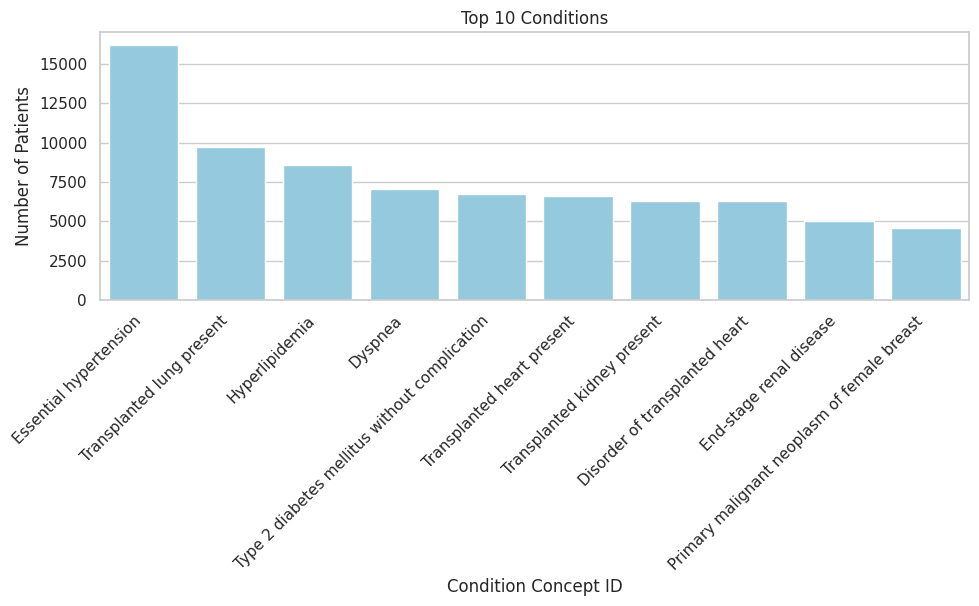

In [29]:
# Count of each condition
top_conditions = person_condition['condition_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_conditions.index, y=top_conditions.values, color='skyblue')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.title("Top 10 Conditions")
plt.ylabel("Number of Patients")
plt.xlabel("Condition Concept ID")
plt.show()

/tmp/ipython-input-4230683911.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


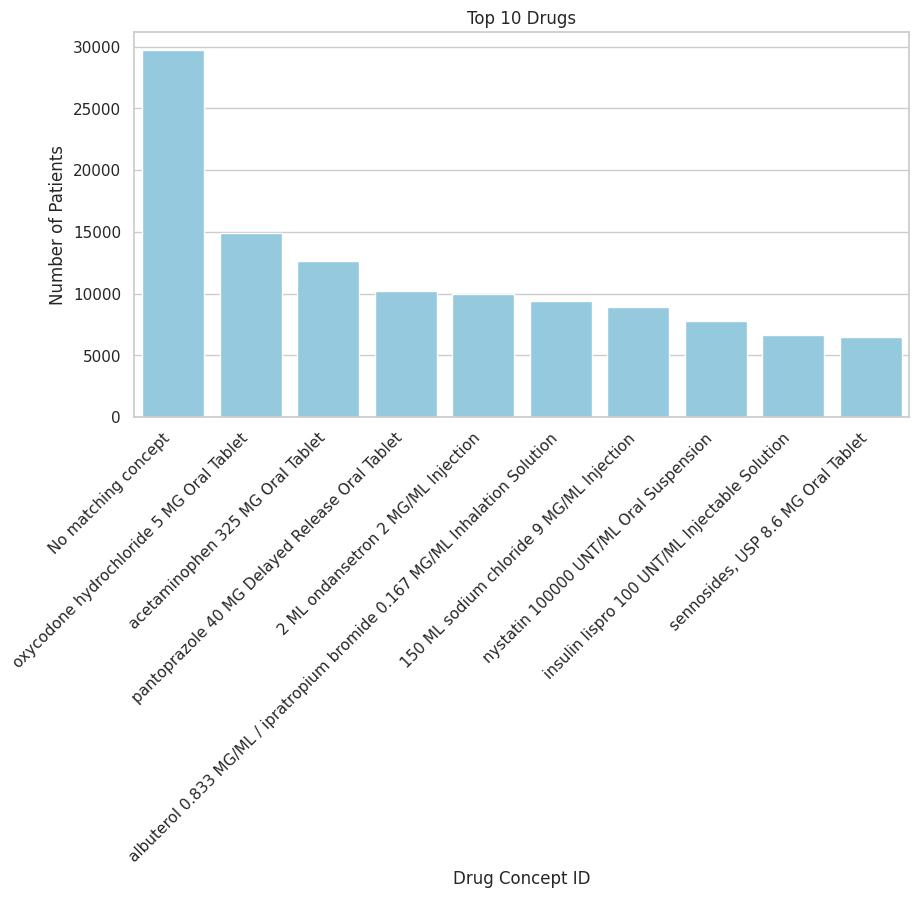

In [30]:
top_drugs = drug_clean['drug_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_drugs.index, y=top_drugs.values, color='skyblue')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.title("Top 10 Drugs")
plt.ylabel("Number of Patients")
plt.xlabel("Drug Concept ID")
plt.show()

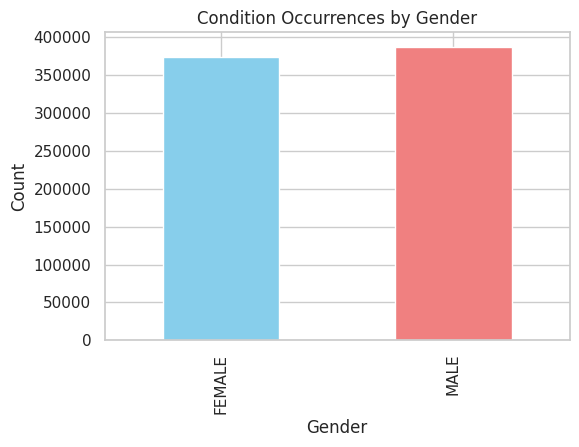

In [31]:
# Map Gender IDs to Gender names using the Concept table
gender_map = dict(concept_clean[concept_clean['domain_id'] == 'Gender'][['concept_id', 'concept_name']].values)

person_condition['gender_name'] = person_condition['gender_concept_id'].map(gender_map)

# Now ploting using gender names
cond_gender = person_condition.groupby('gender_name')['condition_occurrence_id'].count()

plt.figure(figsize=(6,4))
cond_gender.plot(kind='bar', color=['skyblue', 'lightcoral'])

plt.title("Condition Occurrences by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

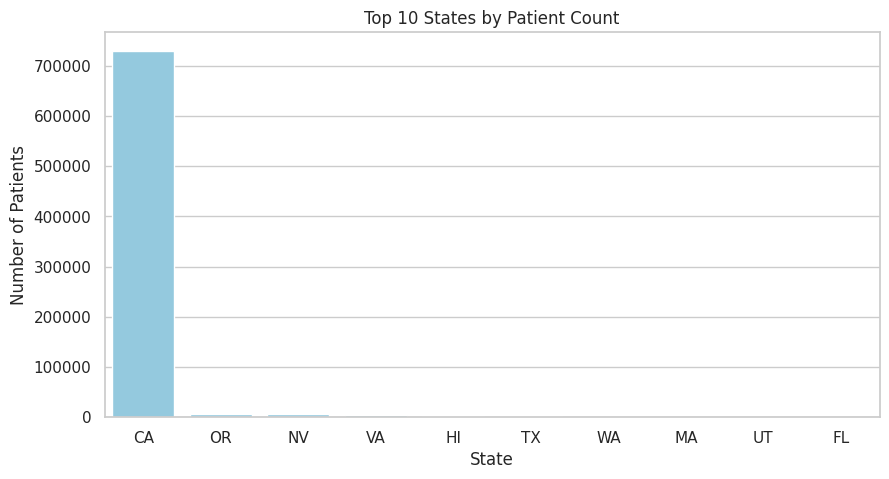

In [32]:
state_counts = person_condition['state'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_counts.index, y=state_counts.values, color='skyblue')

plt.title("Top 10 States by Patient Count")
plt.ylabel("Number of Patients")
plt.xlabel("State")
plt.show()

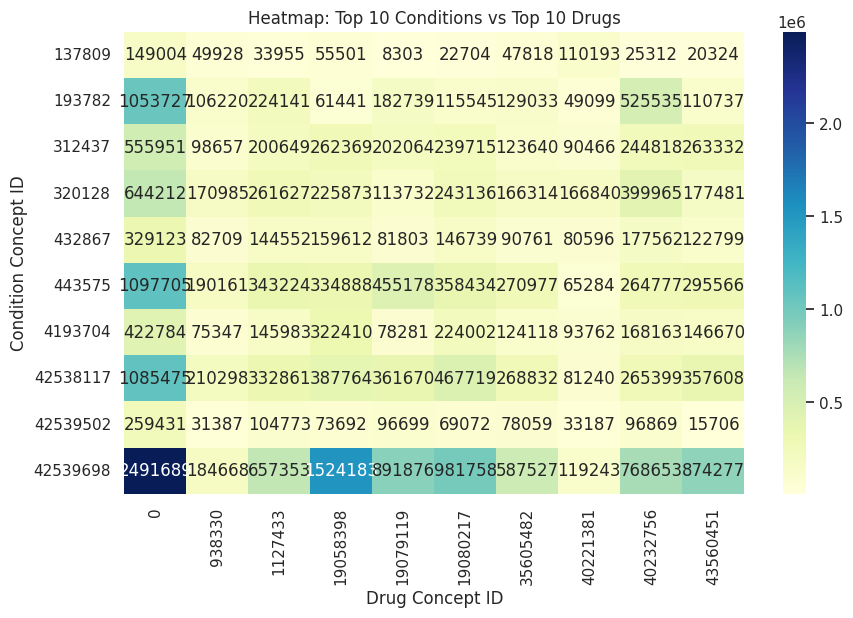

In [33]:
# Get top 10 conditions & drugs by frequency
top_cond_ids = person_condition['condition_concept_id'].value_counts().head(10).index
top_drug_ids = drug_clean['drug_concept_id'].value_counts().head(10).index

# Filter datasets for only top conditions & drugs
person_condition_top = person_condition[person_condition['condition_concept_id'].isin(top_cond_ids)][['person_id', 'condition_concept_id']]
drug_clean_top = drug_clean[drug_clean['drug_concept_id'].isin(top_drug_ids)][['person_id', 'drug_concept_id']]

# Merge on person_id
cond_drug_counts = pd.merge(person_condition_top, drug_clean_top, on='person_id', how='inner')

# Create condition-drug matrix
cond_drug_matrix = cond_drug_counts.groupby(['condition_concept_id', 'drug_concept_id']).size().unstack(fill_value=0)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(cond_drug_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap: Top 10 Conditions vs Top 10 Drugs")
plt.xlabel("Drug Concept ID")
plt.ylabel("Condition Concept ID")
plt.show()

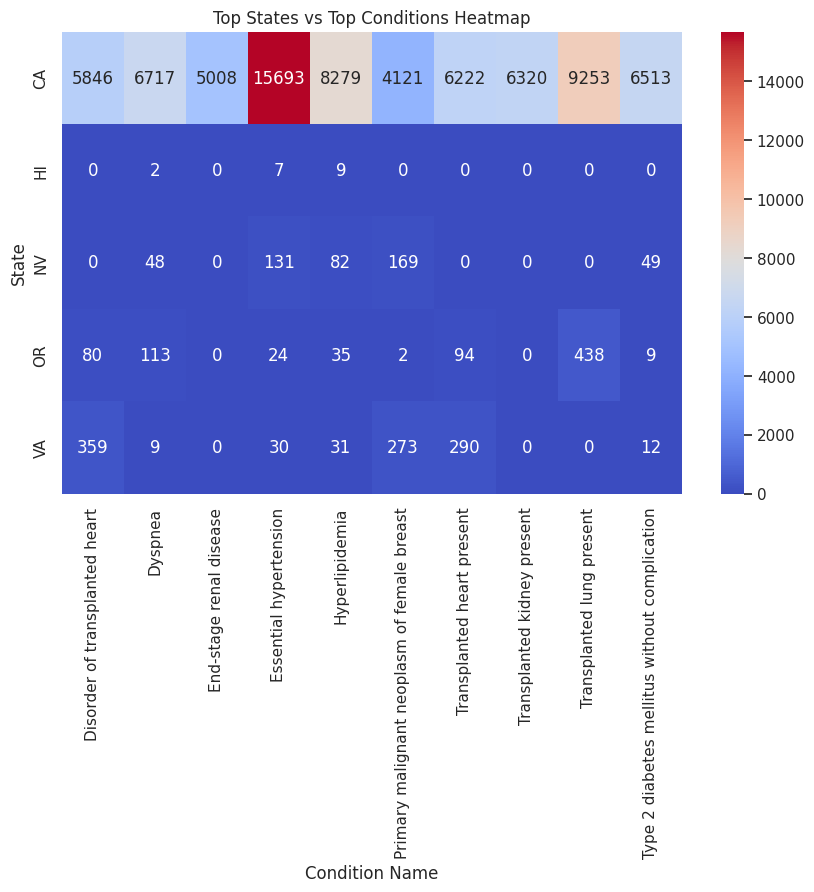

In [34]:
# Top 5 states & top 10 conditions by patient count (using names)
top_states = person_condition['state'].value_counts().head(5).index
top_conditions = person_condition['condition_name'].value_counts().head(10).index

# Filter relevant subset
state_cond_top = person_condition[
    person_condition['state'].isin(top_states) &
    person_condition['condition_name'].isin(top_conditions)
]

# Pivot for heatmap
state_cond_matrix = state_cond_top.groupby(['state', 'condition_name']).size().unstack(fill_value=0)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(state_cond_matrix, annot=True, fmt="d", cmap="coolwarm")
plt.title("Top States vs Top Conditions Heatmap")
plt.xlabel("Condition Name")
plt.ylabel("State")
plt.show()

# ***NETWORK 1: CONDITION - DRUG BIPARTITE NETWORK GRAPH***

In [35]:
# Build Condition–Drug Bipartite Network

# Filter top conditions and drugs for clarity
top_conditions = person_condition['condition_name'].value_counts().head(20).index
top_drugs = drug_clean['drug_name'].value_counts().head(20).index

# Keep only those
person_condition_top = person_condition[person_condition['condition_name'].isin(top_conditions)][['person_id', 'condition_name']]
drug_clean_top = drug_clean[drug_clean['drug_name'].isin(top_drugs)][['person_id', 'drug_name']]

# Merge on person_id to connect conditions - drugs
cond_drug_pairs = pd.merge(person_condition_top, drug_clean_top, on='person_id', how='inner')

# Aggregate — count how many patients share each condition–drug link
cond_drug_edges = cond_drug_pairs.groupby(['condition_name', 'drug_name']).size().reset_index(name='weight')

print("Condition–Drug edge list shape:", cond_drug_edges.shape)
cond_drug_edges.head()

Condition–Drug edge list shape: (400, 3)


,condition_name,drug_name,weight
0,Abnormal findings on diagnostic imaging of lung,"0.5 ML heparin sodium, porcine 10000 UNT/ML In...",78158
1,Abnormal findings on diagnostic imaging of lung,1 ML hydromorphone hydrochloride 1 MG/ML Prefi...,118420
2,Abnormal findings on diagnostic imaging of lung,1 ML hydromorphone hydrochloride 2 MG/ML Injec...,22244
3,Abnormal findings on diagnostic imaging of lung,10 ML furosemide 10 MG/ML Injection,64450
4,Abnormal findings on diagnostic imaging of lung,150 ML sodium chloride 9 MG/ML Injection,48799


In [36]:
# Build NetworkX bipartite graph
B = nx.Graph()

# Add condition nodes
for cond in top_conditions:
    B.add_node(cond, bipartite=0, color='skyblue', title='Condition')

# Add drug nodes
for drug in top_drugs:
    B.add_node(drug, bipartite=1, color='lightgreen', title='Drug')

# Add weighted edges
edges = [(row['condition_name'], row['drug_name'], row['weight']) for _, row in cond_drug_edges.iterrows()]
B.add_weighted_edges_from(edges)

print(f"Graph nodes: {B.number_of_nodes()}, edges: {B.number_of_edges()}")

# Create PyVis Network
net = Network(
    height='700px',
    width='100%',
    bgcolor='white',
    font_color='black',
    notebook=True,
    cdn_resources='in_line'
)

# Add nodes and edges explicitly with colors to preserve them
for node, data in B.nodes(data=True):
    net.add_node(
        node,
        label=node,
        color=data.get('color', 'grey'),
        title=data.get('title', '')
    )

for source, target, data in B.edges(data=True):
    net.add_edge(source, target, value=data.get('weight', 1), title=f"Shared patients: {data.get('weight', 1)}")

# Improve physics & layout
net.toggle_physics(True)
net.repulsion(node_distance=250, central_gravity=0.2, spring_length=100, spring_strength=0.05, damping=0.09)
net.toggle_hide_edges_on_drag(False)
net.toggle_hide_nodes_on_drag(False)

# Save and display graph
html_path = '/content/condition_drug_network.html'
net.save_graph(html_path)
display(HTML(html_path))

Graph nodes: 40, edges: 400


### ***Network Metrices Calculation***

In [37]:
# Define bipartite sets explicitly
condition_set = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 0}
drug_set = set(B) - condition_set

# Weighted degree (strength): sum of weights for edges of each node
weighted_degree_cond = dict(B.degree(condition_set, weight='weight'))
weighted_degree_drug = dict(B.degree(drug_set, weight='weight'))

# Betweenness centrality: weighted, over bipartite graph
betweenness = nx.betweenness_centrality(B, weight='weight')

# Bipartite closeness centrality (unweighted approximation)
closeness_cond = bipartite.closeness_centrality(B, condition_set)
closeness_drug = bipartite.closeness_centrality(B, drug_set)

# Output some example summaries
print("Top 10 conditions by weighted degree:\n")
for node, val in sorted(weighted_degree_cond.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{node}: {val:.1f}")

print("\n\n\nTop 10 conditions by betweenness centrality:\n")
for node, val in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{node}: {val:.4f}")

Top 10 conditions by weighted degree:

Transplanted lung present: 11949529.0
Transplanted heart present: 5442436.0
Disorder of transplanted heart: 5187360.0
Essential hypertension: 3946105.0
End-stage renal disease: 3773684.0
Acute renal failure syndrome: 3529248.0
Dyspnea: 3227979.0
Type 2 diabetes mellitus without complication: 2536051.0
Congestive heart failure: 2331734.0
Pleural effusion: 2207217.0



Top 10 conditions by betweenness centrality:

Primary malignant neoplasm of female breast: 0.3927
1 ML hydromorphone hydrochloride 2 MG/ML Injection: 0.3023
Transplanted kidney present: 0.0810
gabapentin 300 MG Oral Capsule: 0.0729
nystatin 100000 UNT/ML Oral Suspension: 0.0715
Atrial fibrillation: 0.0526
Obstructive sleep apnea syndrome: 0.0472
acetaminophen 500 MG Oral Tablet: 0.0324
famotidine 20 MG Oral Tablet: 0.0310
1 ML hydromorphone hydrochloride 1 MG/ML Prefilled Syringe: 0.0189


In [38]:
# Define bipartite sets
condition_set = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 0}
drug_set = set(B) - condition_set

# Node metrics as before
weighted_degree_cond = dict(B.degree(condition_set, weight='weight'))
weighted_degree_drug = dict(B.degree(drug_set, weight='weight'))
betweenness = nx.betweenness_centrality(B, weight='weight')

# Edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(B, weight='weight')

# Example output: Top Edges by betweenness
top_edges = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 condition-drug edges by betweenness centrality (importance):\n")
for (u, v), val in top_edges:
    print(f"({u} - {v}): {val:.4f} with weight {B.edges[u, v]['weight']}")

# These metrics can be visualized by:
# -> Mapping edge thickness to edge weight or betweenness.
# -> Mapping node sizes to weighted degree.
# -> Showing values as tooltips in PyVis network visualization.

Top 10 condition-drug edges by betweenness centrality (importance):

(Primary malignant neoplasm of female breast - nystatin 100000 UNT/ML Oral Suspension): 0.0949 with weight 8303
(Transplanted kidney present - 1 ML hydromorphone hydrochloride 2 MG/ML Injection): 0.0795 with weight 14184
(Primary malignant neoplasm of female breast - gabapentin 300 MG Oral Capsule): 0.0744 with weight 20445
(Primary malignant neoplasm of female breast - famotidine 20 MG Oral Tablet): 0.0731 with weight 9245
(Atrial fibrillation - 1 ML hydromorphone hydrochloride 2 MG/ML Injection): 0.0667 with weight 12198
(Primary malignant neoplasm of female breast - acetaminophen 500 MG Oral Tablet): 0.0641 with weight 8347
(Transplanted heart present - 1 ML hydromorphone hydrochloride 2 MG/ML Injection): 0.0500 with weight 28017
(Primary malignant neoplasm of female breast - acetaminophen 325 MG Oral Tablet): 0.0500 with weight 33955
(Primary malignant neoplasm of female breast - oxycodone hydrochloride 5 MG Oral 

# ***NETWORK 2: CONDITION - CONDITION CO-OCCURRENCE NETWORK GRAPH***

In [39]:
pair_counter = Counter()

# Incrementally count condition pairs per patient
for pid, group in person_condition.groupby('person_id')['condition_name']:
    if len(group) > 1:
        # Update counts directly without storing all pairs
        pair_counter.update(combinations(sorted(group), 2))

# Convert to DataFrame
cond_cond_edges = pd.DataFrame(pair_counter.items(), columns=['condition_pair', 'weight'])
cond_cond_edges[['condition_1', 'condition_2']] = pd.DataFrame(cond_cond_edges['condition_pair'].tolist(), index=cond_cond_edges.index)
cond_cond_edges.drop(columns=['condition_pair'], inplace=True)

print("Top condition-condition pairs by shared patients:\n")
print(cond_cond_edges.sort_values(by='weight', ascending=False).head(15))

Top condition-condition pairs by shared patients:

         weight                                  condition_1  \
406144  4100552                    Transplanted lung present   
306051  3167416               Disorder of transplanted heart   
311389  1789915                   Transplanted heart present   
305931  1722492               Disorder of transplanted heart   
400828  1087275                    Immunodeficiency disorder   
43122   1046266                                      Dyspnea   
85821    931212                  Transplanted kidney present   
36821    852916                              Cystic fibrosis   
37553    842828       Cystic fibrosis without meconium ileus   
36823    782384                              Cystic fibrosis   
395244   780705                  Disorder of immune function   
37182    761168                  Cystic fibrosis of the lung   
328640   732350         Effect of exposure to physical force   
36995    669631                              Cystic f

In [40]:
# Initialize the interactive network
net = Network(height='750px', width='100%', bgcolor='#ffffff', font_color='black', notebook=True, cdn_resources='remote')
net.force_atlas_2based()

# Count Condition-Condition Co-Occurrence Edges incrementally
edge_weights = defaultdict(int)

for pid, group in person_condition.groupby('person_id')['condition_name']:
    conds = sorted(group.unique())  # unique conditions per patient
    if len(conds) > 1:
        for c1, c2 in combinations(conds, 2):
            edge_weights[(c1, c2)] += 1

# Filter Edges (Limit the Edges with >= 60 shared patients)
edge_threshold = 60
filtered_edges = {k: v for k, v in edge_weights.items() if v >= edge_threshold}

print(f"Edges retained: {len(filtered_edges)} (out of {len(edge_weights)})")

# Determine the Nodes after filtering
node_counts = defaultdict(int)
for (c1, c2), w in filtered_edges.items():
    node_counts[c1] += w
    node_counts[c2] += w

# Filter Nodes by total edge weight ( Considering Nodes with cumulative weight >= 100)
node_threshold = 100
filtered_nodes = {n for n, total_w in node_counts.items() if total_w >= node_threshold}

print(f"Nodes retained: {len(filtered_nodes)}")

# Add filtered Nodes to PyVis with node color
for node in filtered_nodes:
    net.add_node(node, label=node, color='red', title='Condition')

# Add filtered Edges with different colors based on weight or other logic
for (c1, c2), w in filtered_edges.items():
    if c1 in filtered_nodes and c2 in filtered_nodes:
        net.add_edge(c1, c2, value=w, title=f"Shared patients: {w}", color='blue')


net.show("condition_condition_network_filtered_nodes.html")
from IPython.core.display import display, HTML

display(HTML("condition_condition_network_filtered_nodes.html"))

Edges retained: 3540 (out of 2093334)
Nodes retained: 229
condition_condition_network_filtered_nodes.html


In [41]:
# Assume filtered_nodes is a set of nodes from previous filtering work
# Assume filtered_edges is a dict {(node1, node2): weight} after Co-Occurrence threshold filtering

# Initialize empty graph
G = nx.Graph()

# Add filtered nodes
G.add_nodes_from(filtered_nodes)

# Add edges with explicit numeric weights
for (node1, node2), weight in filtered_edges.items():
    if node1 in filtered_nodes and node2 in filtered_nodes:
        G.add_edge(node1, node2, weight=float(weight))

# Diagnostics:Summary
print(f"Number of nodes added to graph: {G.number_of_nodes()}")
print(f"Number of edges added to graph: {G.number_of_edges()}")
print(f"Total sum of edge weights: {G.size(weight='weight')}")

Number of nodes added to graph: 229
Number of edges added to graph: 3514
Total sum of edge weights: 325827.0


# ***Network Metrices Calculation***

In [42]:
# Network density: how interconnected the network is
density = nx.density(G)
print(f"Network density: {density:.4f}")

# Average clustering coefficient: how much nodes tend to cluster together
avg_clustering = nx.average_clustering(G, weight='weight')
print(f"\nAverage clustering coefficient: {avg_clustering:.4f}")

# Diameter: longest shortest path in largest connected component
if nx.is_connected(G):
    diameter = nx.diameter(G)
else:
    largest_cc = max(nx.connected_components(G), key=len)
    diameter = nx.diameter(G.subgraph(largest_cc))
print(f"\nDiameter (largest connected component): {diameter}")

# Degree centrality: importance based on number of connections
deg_centrality = nx.degree_centrality(G)
print("\nTop 5 nodes by degree centrality:")
for node, cent in sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{node}: {cent:.4f}")

# Betweenness centrality: nodes critical for network flow
bet_centrality = nx.betweenness_centrality(G, weight='weight')
print("\nTop 5 nodes by betweenness centrality:")
for node, cent in sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{node}: {cent:.4f}")

# Eigenvector centrality: nodes connected to important nodes
eig_centrality = nx.eigenvector_centrality_numpy(G, weight='weight')
print("\nTop 5 nodes by eigenvector centrality:")
for node, cent in sorted(eig_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{node}: {cent:.4f}")

Network density: 0.1346

Average clustering coefficient: 0.1684

Diameter (largest connected component): 4

Top 5 nodes by degree centrality:
Electrocardiogram abnormal: 0.9474
Essential hypertension: 0.9342
Hyperlipidemia: 0.8509
Dyspnea: 0.7149
Abnormal findings on diagnostic imaging of lung: 0.6491

Top 5 nodes by betweenness centrality:
Hyperlipidemia: 0.1355
Electrocardiogram abnormal: 0.1284
Illness: 0.0769
Dyspnea: 0.0518
Essential hypertension: 0.0484

Top 5 nodes by eigenvector centrality:
Essential hypertension: 0.2630
Electrocardiogram abnormal: 0.2597
Hyperlipidemia: 0.2288
Dyspnea: 0.2032
Abnormal findings on diagnostic imaging of lung: 0.1848


In [43]:
# Sort filtered edges by descending count (weight)
top_pairs = sorted(filtered_edges.items(), key=lambda x: x[1], reverse=True)

print("Top 10 most co-occurring condition pairs:\n")
for (c1, c2), count in top_pairs[:10]:
    print(f"{c1} - {c2}: {count} patients")

Top 10 most co-occurring condition pairs:

Essential hypertension - Hyperlipidemia: 572 patients
Electrocardiogram abnormal - Essential hypertension: 541 patients
Electrocardiogram abnormal - Hyperlipidemia: 446 patients
Dyspnea - Electrocardiogram abnormal: 367 patients
Dyspnea - Essential hypertension: 361 patients
Electrocardiogram abnormal - Pleural effusion: 351 patients
Abnormal findings on diagnostic imaging of lung - Electrocardiogram abnormal: 341 patients
Abnormal findings on diagnostic imaging of lung - Essential hypertension: 332 patients
Chest pain - Electrocardiogram abnormal: 331 patients
Dyspnea - Hyperlipidemia: 318 patients


### ***Community Detection Network***

*   Run Twice



In [45]:
# Community detection using Louvain method
partition = community_louvain.best_partition(G, weight='weight')
num_communities = len(set(partition.values()))
print(f"Number of communities detected: {num_communities}")

# Summarize the Community sizes
comm_sizes = Counter(partition.values())
print("Top Communities by size:")
for comm_id, size in comm_sizes.most_common(5):
    print(f"Community {comm_id}: Size = {size}")

nx.set_node_attributes(G, partition, 'community')
net = Network(height='750px', width='100%', bgcolor='#ffffff', font_color='black', notebook=True, cdn_resources='remote')
net.from_nx(G)

# Color nodes by community
for node in net.nodes:
    community_id = partition[node['id']]
    # Assign colors based on community ID (cycle colors if many communities)
    color_palette = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'yellow']
    node['color'] = color_palette[community_id % len(color_palette)]

# Enable physics layout for better interactivity
net.force_atlas_2based()

# Show interactive network with zoom and pan capabilities
net.show("comorbidity_network_communities.html")

from IPython.core.display import display, HTML
display(HTML("comorbidity_network_communities.html"))

Number of communities detected: 5
Top Communities by size:
Community 1: Size = 106
Community 4: Size = 45
Community 0: Size = 41
Community 3: Size = 29
Community 2: Size = 8
comorbidity_network_communities.html
